In [1]:
# The line below allows to print all the outputs of a cell instead of only the last one
# %config InteractiveShell.ast_node_interactivity = "all"
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

In [2]:
from_script = False

print(f"WARNING: This notebook is set with from_script = {from_script}.")

if from_script:
    # Get the path of the notebook config file from the environment variable
    path_config_notebook = os.environ["PATH_YAML_CONFIG"]
    # Load the notebook config file
    with open(path_config_notebook, "r") as file:
        dict_config_notebook = yaml.safe_load(file)
        print("The dict_config_notebook is:")
        print(dict_config_notebook)
    ID_XP_DATASET = dict_config_notebook["id_xp_dataset"]
    ID_XP = dict_config_notebook["id_xp"]
    PATH_PROJECT = pathlib.Path(dict_config_notebook["path_project"])
    DICT_FILTERS = dict_config_notebook.get("dict_filters", None)
    NAME_SEABORN_COLUMN = dict_config_notebook.get("name_seaborn_column", "env_params_delay_observation")
    NAME_SEABORN_ROW = dict_config_notebook.get("name_seaborn_row", "env_name")
    NAME_SEABORN_HUE = dict_config_notebook.get("name_seaborn_hue", "trainer_name")
    NAME_COLUMN_TO_LOOP_OVER = dict_config_notebook.get(
        "column_to_loop_over", "env_params_mesh"
    )
    NAME_MLFLOW_STORE = dict_config_notebook.get(
        "name_mlflow_store", "mlruns_ruche_downloaded"
    )

    DEBUG_SIZE_FILTER = dict_config_notebook.get("debug_size_filter", None)
else:
    ID_XP_DATASET = 6
    ID_XP = 8
    PATH_PROJECT = pathlib.Path(
        "/home/hosseinkhan/Documents/work/phd/git_repositories/control_dde"
    )
    DICT_FILTERS = {
        "env_name": ["pendulum", "vanderpol"],
    #     "env_params_max_control": [0.0],
    #     "env_params_reynolds": [120.0, 90.0],
    }
    # DICT_FILTERS = {}
    # DEBUG_SIZE_FILTER = 10
    DEBUG_SIZE_FILTER = None
    assert (
        DEBUG_SIZE_FILTER is None or DEBUG_SIZE_FILTER > 0
    ), "DEBUG_SIZE_FILTER must be positive."

    # DICT_FILTERS = None
    NAME_SEABORN_COLUMN = "env_params_delay_observation"
    NAME_SEABORN_ROW = "env_name"
    NAME_SEABORN_HUE = "trainer_name"
    NAME_COLUMN_TO_LOOP_OVER = "data_type"
    NAME_MLFLOW_STORE = "mlruns_ruche_downloaded"

# Add the path of the project to the sys.path in order to import
# the modules in the src folder
sys.path.insert(0, os.path.abspath(PATH_PROJECT))

# Define the paths
path_mlruns = pathlib.Path(f"{PATH_PROJECT}/data/{NAME_MLFLOW_STORE}")
path_experiment_dataset = pathlib.Path(f"{path_mlruns}/{ID_XP_DATASET}")
path_experiment = pathlib.Path(f"{path_mlruns}/{ID_XP}")
# Get all folder in the mlruns/id_xp directory except the folder 'tags'
# using pathlib and iter dir
list_id_hash = [
    path.name
    for path in path_experiment.iterdir()
    if path.is_dir() and path.name != "tags"
]
list_id_hash_dataset = [
    path.name
    for path in path_experiment_dataset.iterdir()
    if path.is_dir() and path.name != "tags"
]

print(f"Number of runs in the dataset: {len(list_id_hash_dataset)} \n")
print(f"Number of runs: {len(list_id_hash)} \n")
print(f"XP id dataset: {ID_XP_DATASET} \n")
print(f"XP id: {ID_XP} \n")

nested_dict_config_dataset = {}
nested_dict_config = {}
list_df_config_flattened_dataset = []
list_df_config_flattened = []


def check_xp_lifecycle(path_file: pathlib.Path):
    if not path_file.exists():
        raise FileNotFoundError(f"The file {path_file} does not exist.")
    if not path_file.is_file():
        raise FileNotFoundError(f"The path {path_file} is not a file.")
    # Load the yaml file
    with open(path_file, "r") as _file:
        dict_temp = yaml.safe_load(_file)
    # Check the lifecycle key
    assert dict_temp.get("lifecycle_stage") == "active", "The experiment is not active."


# Verify all experiments are done on the same environment:
path_xp = f"{path_mlruns}/{ID_XP}"
for name_id in list_id_hash:
    # Check file lifecycle
    list_glob_xp_metadata = list(pathlib.Path(f"{path_xp}/{name_id}").glob("meta.yaml"))
    assert len(list_glob_xp_metadata) != 0, "No metadata file in the directory."
    assert (
        len(list_glob_xp_metadata) == 1
    ), "More than one metadata file in the directory."
    check_xp_lifecycle(list_glob_xp_metadata[0])

    # Get the config file
    list_glob_config = list(
        pathlib.Path(f"{path_xp}/{name_id}/artifacts").glob("./config/*.yaml")
    )
    assert len(list_glob_config) != 0, "No config file in the directory."
    assert len(list_glob_config) == 1, "More than one config file in the directory."

    name_config_file = list_glob_config[0].name
    # Check if the file is a yaml file
    assert name_config_file.endswith(".yaml"), "File is not a yaml file."

    path_run_config_yaml = list_glob_config[0]
    with open(path_run_config_yaml, "r") as file:
        # Get the config file as a dictionary
        dict_config_temp = yaml.safe_load(file)
        # Add the config file to the nested dictionary
        nested_dict_config[name_id] = dict_config_temp
        # Flatten the config file for easier check
        list_df_config_flattened.append(pd.json_normalize(dict_config_temp, sep="_"))
    del dict_config_temp

path_xp_dataset = f"{path_mlruns}/{ID_XP_DATASET}"
for name_id in list_id_hash_dataset:
    list_glob_config = list(
        pathlib.Path(f"{path_xp_dataset}/{name_id}/generated_data").glob(
            "./config/*.yaml"
        )
    )
    assert len(list_glob_config) != 0, "No config file in the directory."
    assert len(list_glob_config) == 1, "More than one config file in the directory."

    name_config_file = list_glob_config[0].name
    # Check if the file is a yaml file
    assert name_config_file.endswith(".yaml"), "File is not a yaml file."

    path_run_config_yaml = list_glob_config[0]
    with open(path_run_config_yaml, "r") as file:
        # Get the config file as a dictionary
        dict_config_temp = yaml.safe_load(file)
        # Add the config file to the nested dictionary
        nested_dict_config_dataset[name_id] = dict_config_temp
        # Flatten the config file for easier check
        list_df_config_flattened_dataset.append(
            pd.json_normalize(dict_config_temp, sep="_")
        )
    del dict_config_temp

Number of runs in the dataset: 9 

Number of runs: 86 

XP id dataset: 6 

XP id: 8 



## DataFrames generation

### DataFrame: Training config

In [3]:
df_trainining_config = (
    pd.concat(
        [
            df_config_flattened.assign(training_id=name_id)
            for name_id, df_config_flattened in zip(
                list_id_hash, list_df_config_flattened
            )
        ]
    )
    .set_index("training_id")
    .pipe(
        lambda df: df.astype(
            {col: "float" for col in df.select_dtypes(include="int").columns}
        )
    )
)

df_trainining_config.head(10)

,mlflow_experiment_name,seed,data_normaliser_name,data_path_data_folder,model_name,model_params_activation,model_params_depth,model_params_dropout,model_params_final_activation,model_params_n_delays,model_params_width_size,trainer_name,trainer_params_bool_discretize_then_optimize,trainer_params_lr_final,trainer_params_lr_init,trainer_params_max_epochs,trainer_params_name_node_interface,trainer_params_pct_trajectory_size,trainer_params_rate_test_set_size,trainer_params_solver
training_id,,,,,,,,,,,,,,,,,,,,
61af45e340174a0fb2108f54c97ee0f8,2024_08_23_training_v2,0.0,standard_normal,data/mlruns/6/8a10495b64e5407090d91eb01b46c5a7...,ncdde,relu,2.0,0.0,identity,1.0,64.0,ncdde,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
1df2f67566fd42d28780873a2af7fe6e,2024_08_23_training_v2,0.0,standard_normal,data/mlruns/6/5497e581024548e0b95621c4509a55ce...,node,relu,2.0,0.0,identity,NaN,64.0,node,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
cf68fcd06e904244afc33b1a479ce44a,2024_08_23_training_v2,1.0,standard_normal,data/mlruns/6/87ec5e0fc69548d5ba0e69c0f4c8694c...,ncde,relu,2.0,0.0,identity,NaN,64.0,ncde,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
cda31db8e9ea4e7f8c6fde42e097b683,2024_08_23_training_v2,1.0,standard_normal,data/mlruns/6/86c03c4c3740431dad24a5b4cc451c40...,node,relu,2.0,0.0,identity,NaN,64.0,node,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
3f318f4a4e8b4362b0303a8f702aa0ac,2024_08_23_training_v2,0.0,standard_normal,data/mlruns/6/86c03c4c3740431dad24a5b4cc451c40...,ncdde,relu,2.0,0.0,identity,1.0,64.0,ncdde,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
85363c1761704713b8aa3ca2a99c1ae0,2024_08_23_training_v2,0.0,standard_normal,data/mlruns/6/6f35c3230f39428c89bda3cae4ad3b7a...,ndde,relu,2.0,0.0,identity,1.0,64.0,ndde,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
ef9e78d7a1614d44b364672b461869a2,2024_08_23_training_v2,0.0,standard_normal,data/mlruns/6/6f35c3230f39428c89bda3cae4ad3b7a...,node,relu,2.0,0.0,identity,NaN,64.0,node,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
e80cb5b6c79c4786987a7e0994581a08,2024_08_23_training_v2,1.0,standard_normal,data/mlruns/6/581bd62a053a4ddf8879fb65d041aba7...,ncde,relu,2.0,0.0,identity,NaN,64.0,ncde,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4
4102e29d9ab142258262f2676e8512fc,2024_08_23_training_v2,1.0,standard_normal,data/mlruns/6/86c03c4c3740431dad24a5b4cc451c40...,ndde,relu,2.0,0.0,identity,1.0,64.0,ndde,True,0.001,0.001,4000.0,torchdde,1.0,0.1,rk4


### DataFrame: Dataset config

In [4]:
df_dataset_config = (
    pd.concat(
        [
            df_config_flattened.assign(dataset_id=name_id)
            for name_id, df_config_flattened in zip(
                list_id_hash_dataset, list_df_config_flattened_dataset
            )
        ]
    )
    .set_index("dataset_id")
    .pipe(
        lambda df: df.astype(
            {col: "float" for col in df.select_dtypes(include="int").columns}
        )
    )
)

df_dataset_config.head(10)

,mlflow_experiment_name,seed,data_control_type,data_num_steps,data_num_trajectories,data_type,env_name,env_params_beta,env_params_delay_observation,env_params_dict_initial_condition_std,env_params_dict_initial_condition_type,env_params_dt,env_params_gamma,env_params_n,env_params_tau
dataset_id,,,,,,,,,,,,,,,
86c03c4c3740431dad24a5b4cc451c40,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,mackey_glass,2.0,0.01,0.1,nonzero,0.1,1.0,7.0,3.0
1f43506f737b4ca6ac16ab3335c6e4cd,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,vanderpol,NaN,0.01,0.1,zero,0.1,NaN,NaN,NaN
581bd62a053a4ddf8879fb65d041aba7,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,vanderpol,NaN,0.10,0.1,zero,0.1,NaN,NaN,NaN
5497e581024548e0b95621c4509a55ce,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,pendulum,NaN,0.01,0.1,bottom,0.1,NaN,NaN,NaN
87ec5e0fc69548d5ba0e69c0f4c8694c,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,mackey_glass,2.0,0.10,0.1,nonzero,0.1,1.0,7.0,3.0
cf34cb80cddc497c900dbd62e9958e60,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,mackey_glass,2.0,0.00,0.1,nonzero,0.1,1.0,7.0,3.0
8b885c1be6c147ceb9811fce04a7fa01,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,vanderpol,NaN,0.00,0.1,zero,0.1,NaN,NaN,NaN
8a10495b64e5407090d91eb01b46c5a7,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,pendulum,NaN,0.00,0.1,bottom,0.1,NaN,NaN,NaN
6f35c3230f39428c89bda3cae4ad3b7a,2024_08_12_training_data_v2,0.0,uniform,100.0,400.0,multiple_trajectories,pendulum,NaN,0.10,0.1,bottom,0.1,NaN,NaN,NaN


In [5]:
print("Unique values of the dataset DataFrame")
print(df_dataset_config.nunique())
for column in df_dataset_config.columns:
    print(f"{column}: {df_dataset_config[column].unique()}")

Unique values of the dataset DataFrame
mlflow_experiment_name                    1
seed                                      1
data_control_type                         1
data_num_steps                            1
data_num_trajectories                     1
data_type                                 1
env_name                                  3
env_params_beta                           1
env_params_delay_observation              3
env_params_dict_initial_condition_std     1
env_params_dict_initial_condition_type    3
env_params_dt                             1
env_params_gamma                          1
env_params_n                              1
env_params_tau                            1
dtype: int64
mlflow_experiment_name: ['2024_08_12_training_data_v2']
seed: [0.]
data_control_type: ['uniform']
data_num_steps: [100.]
data_num_trajectories: [400.]
data_type: ['multiple_trajectories']
env_name: ['mackey_glass' 'vanderpol' 'pendulum']
env_params_beta: [ 2. nan]
env_params_delay_observ

### DataFrame: Training and dataset config merged

#### Filtering DataFrame

In [6]:
# Filtering function based on the DICT_FILTERS
def filter_dataframe(df: pd.DataFrame):
    mask = pd.Series([True] * len(df), index=df.index)
    if DICT_FILTERS is None:
        return mask
    else:
        for key, list_values in DICT_FILTERS.items():
            if key in df.columns:
                mask = mask & df[key].isin(list_values)
            else:
                print(f"Warning: The key {key} is not in the config file.")
    return mask


df_training_dataset_merged = (
    df_trainining_config.assign(
        dataset_id=lambda _x: _x.data_path_data_folder.str.extract(
            rf"{ID_XP_DATASET}/(.*?)/generated_data"
        )
    )
    .join(df_dataset_config, on="dataset_id", rsuffix="_dataset")
    .fillna({"model_params_n_delays": 0.0})
    .drop(columns=["data_path_data_folder"])
    .loc[lambda df: filter_dataframe(df)]
)

In [7]:
df_training_dataset_merged.head(10)

,mlflow_experiment_name,seed,data_normaliser_name,model_name,model_params_activation,model_params_depth,model_params_dropout,model_params_final_activation,model_params_n_delays,model_params_width_size,...,data_type,env_name,env_params_beta,env_params_delay_observation,env_params_dict_initial_condition_std,env_params_dict_initial_condition_type,env_params_dt,env_params_gamma,env_params_n,env_params_tau
training_id,,,,,,,,,,,,,,,,,,,,,
61af45e340174a0fb2108f54c97ee0f8,2024_08_23_training_v2,0.0,standard_normal,ncdde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,pendulum,NaN,0.00,0.1,bottom,0.1,NaN,NaN,NaN
1df2f67566fd42d28780873a2af7fe6e,2024_08_23_training_v2,0.0,standard_normal,node,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,pendulum,NaN,0.01,0.1,bottom,0.1,NaN,NaN,NaN
85363c1761704713b8aa3ca2a99c1ae0,2024_08_23_training_v2,0.0,standard_normal,ndde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,pendulum,NaN,0.10,0.1,bottom,0.1,NaN,NaN,NaN
ef9e78d7a1614d44b364672b461869a2,2024_08_23_training_v2,0.0,standard_normal,node,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,pendulum,NaN,0.10,0.1,bottom,0.1,NaN,NaN,NaN
e80cb5b6c79c4786987a7e0994581a08,2024_08_23_training_v2,1.0,standard_normal,ncde,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.10,0.1,zero,0.1,NaN,NaN,NaN
90f0bdd2cba04c05bc3426387b648da8,2024_08_23_training_v2,1.0,standard_normal,node,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.01,0.1,zero,0.1,NaN,NaN,NaN
ed384ef50a514b4ca5244ddd8d62d9fd,2024_08_23_training_v2,1.0,standard_normal,ncdde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,pendulum,NaN,0.00,0.1,bottom,0.1,NaN,NaN,NaN
c5680895d99e4fcb8244761d63dc2052,2024_08_23_training_v2,1.0,standard_normal,ndde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,pendulum,NaN,0.00,0.1,bottom,0.1,NaN,NaN,NaN
0f48bec86369426482317d97f37baf0c,2024_08_23_training_v2,0.0,standard_normal,ncde,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.01,0.1,zero,0.1,NaN,NaN,NaN


In [8]:
df_training_dataset_merged.shape

(57, 35)

### DataFrame: Training metrics

In [9]:
# noinspection PyUnresolvedReferences
import tbparse

In [10]:
list_df_run_tb_data = []
list_id_hash_filtered = list(df_training_dataset_merged.index)

if DEBUG_SIZE_FILTER is not None:
    list_id_hash_filtered = list_id_hash_filtered[:DEBUG_SIZE_FILTER]
list_id_hash_filtered = list_id_hash_filtered

for name_id in list_id_hash_filtered:
    path_run_config_folder = (
        f"{path_xp}/{name_id}/generated_data/trainer_data/ode_trainer"
    )
    # Get the files which have "tfevents" in their name
    list_files = [
        path.name for path in pathlib.Path(path_run_config_folder).glob("*tfevents*")
    ]
    assert len(list_files) == 1, f"More than one file in {path_run_config_folder}"
    path_run_config_file = f"{path_run_config_folder}/{list_files[0]}"
    # Load config with tbparser
    # noinspection PyPackageRequirements

    tb_reader = tbparse.SummaryReader(path_run_config_file)
    df_run_tb_data = tb_reader.scalars
    list_df_run_tb_data.append(df_run_tb_data)

In [11]:
df_tb_data = pd.concat(
    list_df_run_tb_data,
    # axis="columns",
    keys=list_id_hash_filtered,
    names=["run_id", "episode_data"],
).rename(columns={"tag": "metric"})
df_tb_data.head()

step           metric  \
run_id                           episode_data                          
61af45e340174a0fb2108f54c97ee0f8 0               50  magnitude/truth   
                                 1               50  magnitude/truth   
                                 2               50  magnitude/truth   
                                 3               50  magnitude/truth   
                                 4              100  magnitude/truth   

                                                   value  
run_id                           episode_data             
61af45e340174a0fb2108f54c97ee0f8 0              3.375423  
                                 1              4.932280  
                                 2              3.292071  
                                 3              3.417500  
                                 4             17.489729

In [12]:
df_tb_data.metric.unique()

array(['magnitude/truth', 'mean_loss_over_batches/eval',
       'mean_loss_over_batches/train'], dtype=object)

In [13]:
df_training_dataset_merged.sample(frac=1).head(10)

,mlflow_experiment_name,seed,data_normaliser_name,model_name,model_params_activation,model_params_depth,model_params_dropout,model_params_final_activation,model_params_n_delays,model_params_width_size,...,data_type,env_name,env_params_beta,env_params_delay_observation,env_params_dict_initial_condition_std,env_params_dict_initial_condition_type,env_params_dt,env_params_gamma,env_params_n,env_params_tau
training_id,,,,,,,,,,,,,,,,,,,,,
817dea0299754d57bf80b6b57e7122f3,2024_08_23_training_v2,0.0,standard_normal,ncde,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.00,0.1,zero,0.1,NaN,NaN,NaN
5a0197dba4df4d23a33dc871705a6d68,2024_08_23_training_v2,1.0,standard_normal,ndde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.01,0.1,zero,0.1,NaN,NaN,NaN
7343209f87dd4be7a94830e1efda5b0b,2024_08_23_training_v2,1.0,standard_normal,node,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.00,0.1,zero,0.1,NaN,NaN,NaN
2ac8785f2aa74540861f1f026502d485,2024_08_23_training_v2,1.0,standard_normal,ndde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.10,0.1,zero,0.1,NaN,NaN,NaN
d5d2261bdc5249d5b11e37cd7d5d0b27,2024_08_23_training_v2,1.0,standard_normal,ncde,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.00,0.1,zero,0.1,NaN,NaN,NaN
ca2ad0a8feaf490a8987e6c48062f0fa,2024_08_23_training_v2,1.0,standard_normal,ncde,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.01,0.1,zero,0.1,NaN,NaN,NaN
826a8f2e82b244b58f68f490e7fe7a32,2024_08_23_training_v2,1.0,standard_normal,node,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,pendulum,NaN,0.00,0.1,bottom,0.1,NaN,NaN,NaN
6cf0bb6bf7ed401b90e64910096632ed,2024_08_23_training_v2,0.0,standard_normal,ncde,relu,2.0,0.0,identity,0.0,64.0,...,multiple_trajectories,pendulum,NaN,0.10,0.1,bottom,0.1,NaN,NaN,NaN
6103585a07b44d47abd45201f6eadc6a,2024_08_23_training_v2,0.0,standard_normal,ncdde,relu,2.0,0.0,identity,1.0,64.0,...,multiple_trajectories,vanderpol,NaN,0.01,0.1,zero,0.1,NaN,NaN,NaN


In [14]:
df_all_data = (
    df_tb_data.join(df_training_dataset_merged, on="run_id")
    # .set_index(df_training_dataset_merged.columns.tolist(), append=True)
)

In [15]:
df_all_data.loc[df_all_data.metric.str.contains("loss")].metric.unique()

array(['mean_loss_over_batches/eval', 'mean_loss_over_batches/train'],
      dtype=object)

In [16]:
NAME_SEABORN_COLUMN = "env_params_delay_observation"
NAME_SEABORN_ROW = "env_name"
NAME_SEABORN_HUE = "model_name"
NAME_COLUMN_TO_LOOP_OVER = "data_type"

list_unique_values_column_to_loop_over = df_all_data[NAME_COLUMN_TO_LOOP_OVER].unique()
list_unique_values_seaborn_column = df_all_data[NAME_SEABORN_COLUMN].unique()
list_unique_values_seaborn_row = df_all_data[NAME_SEABORN_ROW].unique()

for value in list_unique_values_column_to_loop_over:
    print(f"Column values to loop over: {value}")

for value in list_unique_values_seaborn_column:
    print(f"Column values for seaborn column: {value}")

for value in list_unique_values_seaborn_row:
    print(f"Column values for seaborn row: {value}")

Column values to loop over: multiple_trajectories
Column values for seaborn column: 0.0
Column values for seaborn column: 0.01
Column values for seaborn column: 0.1
Column values for seaborn row: pendulum
Column values for seaborn row: vanderpol


In [17]:
DICT_COL_DISPLAY_NAME = {
    "env_params_delay_observation": "$\\tau$",
    "env_params_mesh": "Mesh",
    "env_name": "Env",
    "trainer_name": "Trainer",
    "data_type": "Data type",
    "value": "$\\mathcal{L}$",
    "model_name": "Model",
    "metric": "Metric",
    "step": "Epochs",
}

DICT_VALUE_DISPLAY_NAME = {
    "node": "NODE",
    "ncde": "NCDE",
    "ndde": "NDDE",
    "ncdde": "NCDDE",
    "mean_loss_over_batches/train": "Train",
    "mean_loss_over_batches/eval": "Validation",
    "mackey_glass": "Mackey-Glass",
    "pendulum": "Pendulum",
    "vanderpol": "Van der Pol",
}

COLOR_PALETTE = {
    "NODE": "forestgreen",
    "NCDE": "limegreen",
    "NDDE": "blue",
    "NCDDE": "skyblue",
}

FONT_SIZE = 12
import matplotlib
plt.style.use("data/matplotlib_config/stylesheet.mplstyle")
sns.set_theme(rc={'figure.figsize':matplotlib.rcParams['figure.figsize']}, style="white")
sns.set_style(style="whitegrid")

COLUMN VALUE: multiple_trajectories


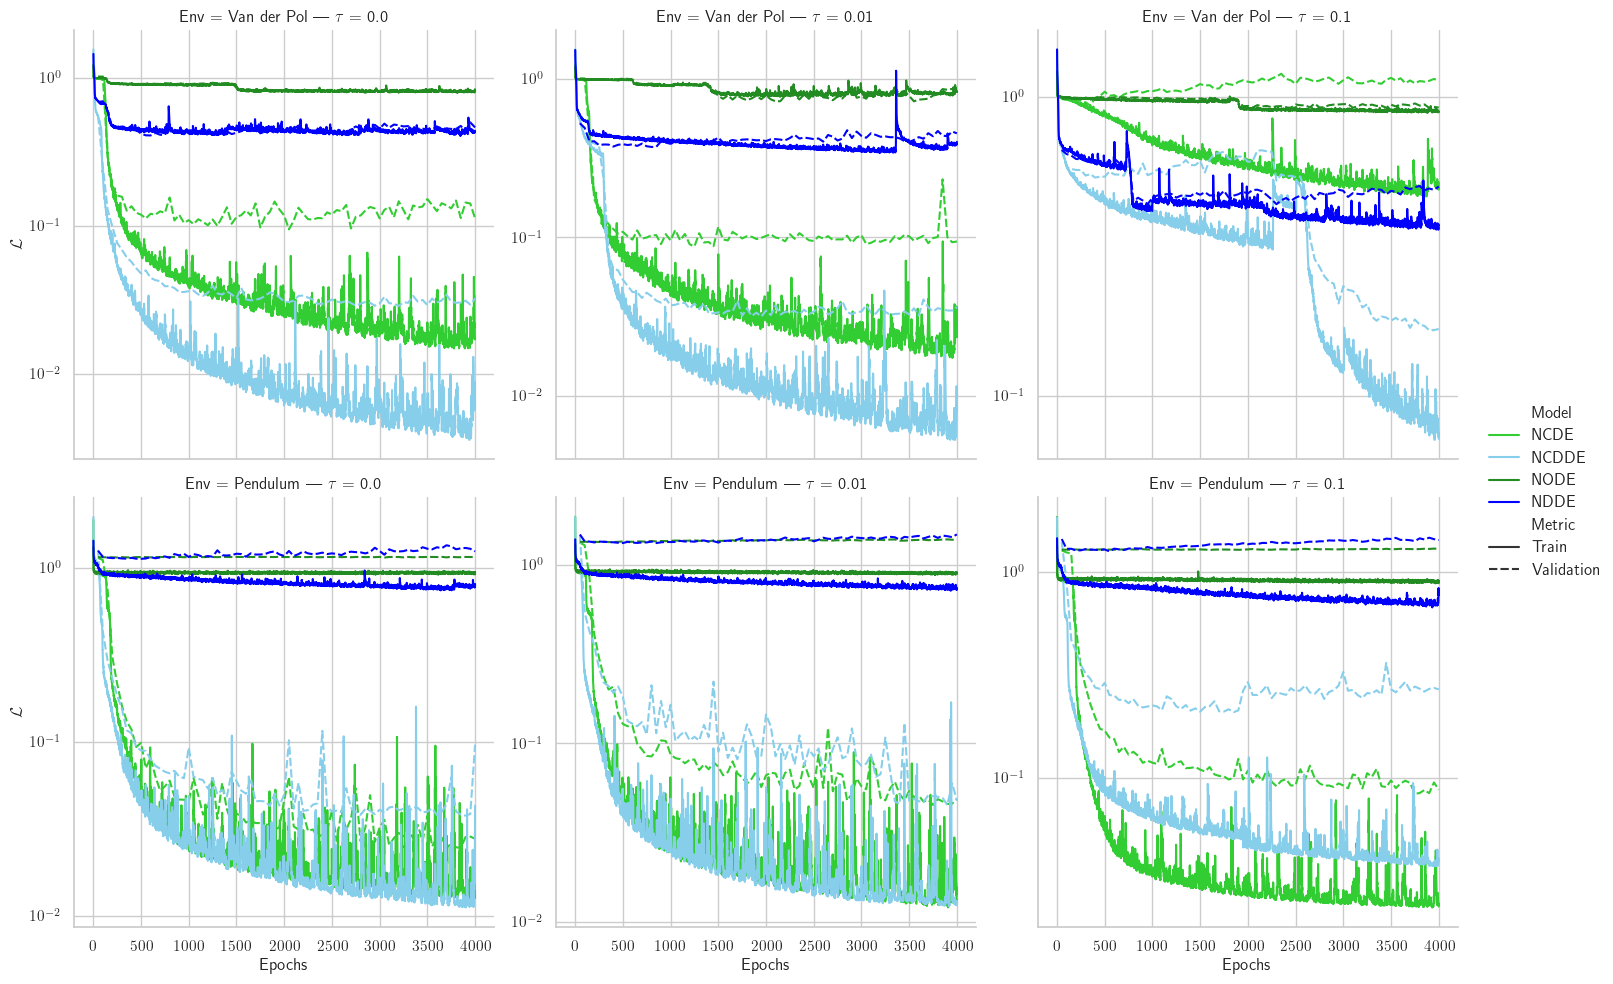

In [18]:
# plt.style.use('data/matplotlib_config/stylesheet.mplstyle')

list_unique_values_column_to_loop_over = df_all_data[NAME_COLUMN_TO_LOOP_OVER].unique()

height = matplotlib.rcParams['figure.figsize'][1]
width = matplotlib.rcParams['figure.figsize'][0]

for column_value in list_unique_values_column_to_loop_over:
    print(f"COLUMN VALUE: {column_value}")

    df_sns = (
        df_all_data.loc[df_all_data[NAME_COLUMN_TO_LOOP_OVER] == column_value]
        .loc[df_all_data.metric.str.contains("loss")]
        .rename(columns=DICT_COL_DISPLAY_NAME)
        .replace(DICT_VALUE_DISPLAY_NAME)
        .sample(frac=1)
    )
    # Get unique values of the "ent_coef" column
    n_cols = len(df_sns[DICT_COL_DISPLAY_NAME[NAME_SEABORN_COLUMN]].unique())
    # n_cols = 1
    # aspect = width / (height * n_cols)


# Create target directory & all intermediate directories if don't exists
    pathlib.Path(f"./data/figures/2024_12_06_visualisation_training_results_phd_thesis_toy_models").mkdir(
        parents=True, exist_ok=True)

    sns_plot = sns.relplot(
        data=df_sns,
        x=DICT_COL_DISPLAY_NAME["step"],
        y=DICT_COL_DISPLAY_NAME["value"],
        style=DICT_COL_DISPLAY_NAME["metric"],
        kind="line",
        hue=DICT_COL_DISPLAY_NAME[NAME_SEABORN_HUE],
        row=DICT_COL_DISPLAY_NAME[NAME_SEABORN_ROW],
        # col="delay_obs",
        col=DICT_COL_DISPLAY_NAME[NAME_SEABORN_COLUMN],
        # no confidence interval
        errorbar=None,
        # No sharing of the y-axis
        facet_kws={
            "sharey": False,
        },
        palette=COLOR_PALETTE,
        # height=height,
        # aspect=aspect,
    )
    # Y-scale is logarithmic
    sns_plot.set(yscale="log")
    # Set the size of the figure axis inside the plot
    
    sns_plot.set_xlabels(fontsize=FONT_SIZE)
    sns_plot.set_ylabels(fontsize=FONT_SIZE)
    sns_plot.set_titles(fontsize=FONT_SIZE)
    plt.setp(sns_plot._legend.get_texts(), fontsize=FONT_SIZE) # for legend text
    plt.setp(sns_plot._legend.get_title(), fontsize=FONT_SIZE)
    # plt.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

    sns_plot.tight_layout()
    # g.fig.set_figwidth(4.7)  # TODO: REMOVE
    # g.fig.set_figheight(3.5)
    # Save the plot as a pgf file and a png file
    sns_plot.savefig(
        f"./data/figures/2024_12_06_visualisation_training_results_phd_thesis_toy_models/"
        f"training_results_{column_value}.pgf"
    )
    sns_plot.savefig(f"./data/figures/2024_12_06_visualisation_training_results_phd_thesis_toy_models/"
                        f"training_results_{column_value}.png")
    plt.show()